In [2]:
import numpy as np
import hockey.hockey_env as h_env
import gymnasium as gym
from importlib import reload
import time

In [3]:
np.set_printoptions(suppress=True)

In [4]:
reload(h_env)

/home/tomf/.pyenv/versions/3.12.5/envs/reinforce-the-puck/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment Hockey-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/tomf/.pyenv/versions/3.12.5/envs/reinforce-the-puck/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment Hockey-One-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


<module 'hockey.hockey_env' from '/home/tomf/.pyenv/versions/3.12.5/envs/reinforce-the-puck/lib/python3.12/site-packages/hockey/hockey_env.py'>

# Normal Game Play

In [5]:
env = h_env.HockeyEnv()

have a look at the initialization condition: alternating who starts and are random in puck position

In [6]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
_ = env.render()

one episode with random agents

In [7]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()

for _ in range(600):
    env.render(mode="human")
    a1 = np.random.uniform(-1, 1, 4)
    a2 = np.random.uniform(-1, 1, 4)
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

obs, obs_agent2

(array([ -0.8235755 ,   0.54478741,   0.87586319,  -2.48319459,
         -1.25584424,   1.66710687,   1.01117277,  -2.66448784,
          0.71141225,  -1.71854484,   3.04892778,   2.30105686,
         -4.34686518,   0.15324211, -17.23440552,  11.77890205,
          0.        ,   0.        ]),
 array([ -1.01117277,   2.66448784,   0.71141225,   1.71854484,
         -3.04892778,   2.30105686,   0.8235755 ,  -0.54478741,
          0.87586319,   2.48319459,   1.25584424,   1.66710687,
          4.34686518,  -0.15324211,  17.23440552, -11.77890205,
          0.        ,   0.        ]))

Without rendering, it runs much faster

"info" dict contains useful proxy rewards and winning information

In [8]:
info, env.get_info_agent_two()

({'winner': -1,
  'reward_closeness_to_puck': -0.20419081851590998,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -0.0027575048828125002},
 {'winner': 1,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 0.0027575048828125002})

Winner == 0: draw

Winner == 1: you (left player)

Winner == -1: opponent wins (right player)

In [9]:
env.close()

# Train Shooting

In [10]:
env = h_env.HockeyEnv(mode=1)

In [11]:
o, info = env.reset()
_ = env.render()

for _ in range(1000):
    env.render()
    a1 = [1, 0, 0, 1]  # np.random.uniform(-1,1,4)
    a2 = [0, 0.0, 0, 0]
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

In [12]:
env.close()

# Train DEFENDING

In [13]:
env = h_env.HockeyEnv(mode=2)

In [14]:
o, info = env.reset()
_ = env.render()

for _ in range(60):
    env.render()
    a1 = [0.1, 0, 0, 1]  # np.random.uniform(-1,1,3)
    a2 = [0, 0.0, 0, 0]
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    print(r)
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

0.0
-0.5158552840723035
-0.3780256972565895
-0.2684857365708585
-0.18286174656908102
-0.10653914509420194
-0.07738526413195024
-0.15067265917276332
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
10.0


In [15]:
env.close()

# Using discrete actions

In [16]:
import random

In [17]:
env = h_env.HockeyEnv(mode=1)

In [18]:
env.reset()
for _ in range(251):
    env.render()
    a1_discrete = random.randint(0, 7)
    a1 = env.discrete_to_continous_action(a1_discrete)
    a2 = [0, 0.0, 0, 0]
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

In [19]:
env.close()

# Hand-crafted Opponent

In [28]:
env = h_env.HockeyEnv()
env.action_space

Box(-1.0, 1.0, (8,), float32)

In [21]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent()

In [29]:
obs_buffer = []
reward_buffer = []
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
for _ in range(1000):
    env.render()
    a1 = player1.act(obs)
    a2 = player2.act(obs_agent2)
    print(obs.shape)
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_buffer.append(obs)
    reward_buffer.append(r)
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)

(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,)
(18,

In [23]:
np.mean(obs_buffer, axis=0)

array([-2.62826682,  0.21303847, -0.03492098, -0.28166533,  0.05138724,
       -0.45329947,  2.42675076, -0.04994422, -0.05127504,  0.21125499,
        0.38315378,  0.09028614,  0.11334929,  0.16926354,  4.13526311,
       -0.23633899,  2.8       ,  1.4       ])

In [24]:
np.std(obs_buffer, axis=0)

array([ 0.64539548,  0.2570889 ,  0.63279509,  5.16908653,  1.98976229,
        3.39210066,  0.96110433,  0.23190633,  0.13068389,  5.05977588,
        1.19524175,  0.6476215 ,  1.92330975,  1.22094677, 16.94342276,
       14.7835668 ,  4.87442304,  3.72021505])

If you want to use a fixed observation scaling, this might be a reasonable choice

In [25]:
scaling = [
    1.0,
    1.0,
    0.5,
    4.0,
    4.0,
    4.0,
    1.0,
    1.0,
    0.5,
    4.0,
    4.0,
    4.0,
    2.0,
    2.0,
    10.0,
    10.0,
    4,
    0,
    4,
    0,
]

In [26]:
import pylab as plt

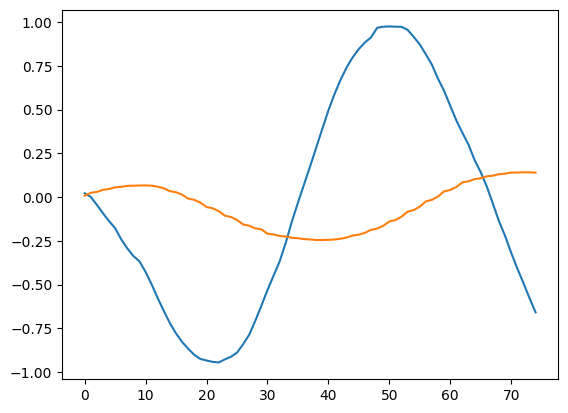

In [27]:
plt.plot(obs_buffer[:, 2])
plt.plot(obs_buffer[:, 8])

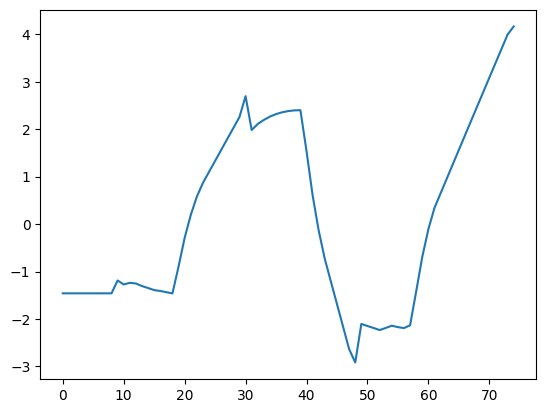

In [28]:
plt.plot(obs_buffer[:, 12])

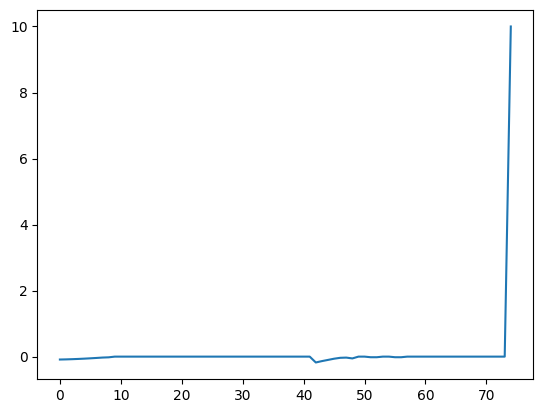

In [29]:
plt.plot(reward_buffer[:])

In [30]:
np.sum(reward_buffer)

8.811598942709278

In [31]:
info2 = env.get_info_agent_two()
info, info2, env.get_reward(info), env.get_reward_agent_two(info2)

({'winner': 1,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -0.0002514656448364258},
 {'winner': -1,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 0.0002514656448364258},
 10.0,
 -10.0)

In [30]:
env.close()

# Human Opponent

In [33]:
env = h_env.HockeyEnv()

In [34]:
player1 = h_env.HumanOpponent(env=env, player=1)
player2 = h_env.BasicOpponent()

Human Controls:
 left:			left arrow key left
 right:			arrow key right
 up:			arrow key up
 down:			arrow key down
 tilt clockwise:	w
 tilt anti-clockwise:	s
 shoot :	space


In [35]:
player1 = h_env.BasicOpponent()
player2 = h_env.HumanOpponent(env=env, player=2)

Human Controls:
 left:			left arrow key left
 right:			arrow key right
 up:			arrow key up
 down:			arrow key down
 tilt clockwise:	w
 tilt anti-clockwise:	s
 shoot :	space


In [36]:
obs, info = env.reset()

env.render()
time.sleep(1)
obs_agent2 = env.obs_agent_two()
for _ in range(100):
    time.sleep(0.2)
    env.render()
    a1 = player1.act(obs)
    a2 = player2.act(obs_agent2)
    obs, r, d, _, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d:
        break

In [37]:
env.close()

# Check side consistency

In [38]:
env = h_env.HockeyEnv()

In [39]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent(weak=False)

In [40]:
obs_buffer = []
reward_buffer = []
obs2_buffer = []
winner_buffer = []
reward2_buffer = []
for game in range(1000):
    obs, info = env.reset()
    obs_agent2 = env.obs_agent_two()
    for _ in range(500):
        # env.render()
        a1 = player1.act(obs)
        a2 = player2.act(obs_agent2)
        #        a1 = np.random.uniform(-1,1,4)
        #        a2 = np.random.uniform(-1,1,4)
        obs, r, d, t, info = env.step(np.hstack([a1, a2]))
        info2 = env.get_info_agent_two()
        r2 = env.get_reward_agent_two(info2)
        obs_buffer.append(obs)
        obs_agent2 = env.obs_agent_two()
        obs2_buffer.append(obs_agent2)
        reward_buffer.append(r)
        reward2_buffer.append(r2)
        if d or t:
            winner_buffer.append(info["winner"])
            break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)
obs2_buffer = np.asarray(obs2_buffer)
reward2_buffer = np.asarray(reward2_buffer)

TypeError: unsupported operand type(s) for +: 'b2Vec2' and 'float'

In [73]:
obs_buffer.shape

(151565, 18)

In [74]:
np.mean(obs_buffer, axis=0)

array([-2.97888106,  0.00001797, -0.00132799, -0.05613033,  0.01595334,
       -0.01055253,  2.97794889,  0.00667539, -0.00167648,  0.05204013,
        0.0126001 , -0.00480013, -0.01689268,  0.01444878,  0.03788336,
        0.00988088,  1.08557385,  1.09107644])

In [75]:
(np.std(obs_buffer, axis=0) - np.std(obs2_buffer, axis=0)) / np.std(obs_buffer, axis=0)

array([-0.00048196, -0.01675039, -0.00086126,  0.00185331, -0.01168299,
        0.00219509,  0.00048173,  0.01647443,  0.00086052, -0.00185675,
        0.01154807, -0.00219992,  0.        ,  0.        ,  0.        ,
        0.        , -0.00227019,  0.00226505])

In [76]:
winner_buffer

[-1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 -1,
 0,
 0,
 1,
 0,
 -1,
 1,
 0,
 -1,
 0,
 -1,
 0,
 1,
 0,
 -1,
 1,
 0,
 1,
 -1,
 0,
 0,
 1,
 1,
 0,
 1,
 -1,
 1,
 1,
 -1,
 0,
 -1,
 1,
 0,
 1,
 0,
 0,
 1,
 -1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 -1,
 0,
 0,
 0,
 -1,
 0,
 -1,
 0,
 -1,
 0,
 -1,
 -1,
 -1,
 1,
 -1,
 0,
 0,
 1,
 -1,
 1,
 1,
 -1,
 0,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 -1,
 0,
 1,
 1,
 -1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 -1,
 1,
 1,
 1,
 0,
 -1,
 1,
 1,
 -1,
 1,
 0,
 1,
 0,
 -1,
 -1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 -1,
 0,
 0,
 0,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 -1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 -1,
 1,
 -1,
 0,
 -1,
 -1,
 1,
 -1,
 -1,
 0,
 -1,
 0,
 1,
 1,
 -1,
 0,
 1,
 1,
 -1,
 1,
 0,
 1,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 -1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 0,
 0,
 1,
 1,
 -1,
 0,
 1,
 0,
 1,
 -1,
 -1,
 1,
 0,
 0,
 -1,
 0,
 -1,
 

In [77]:
np.mean(winner_buffer, axis=0)

0.028

In [78]:
np.std(winner_buffer, axis=0)

0.8044973586034948

In [79]:
np.sum(reward_buffer), np.sum(reward2_buffer)

(-4117.950451598011, -4617.018920846469)

In [80]:
env.close()